In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    # biar ga kepanjangan, cuma tampilin folder + jumlah file
    print(root, '->', len(files), 'file')

/kaggle/input -> 0 file
/kaggle/input/datasets -> 0 file
/kaggle/input/datasets/muhammadfarhanalafif -> 0 file
/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026 -> 0 file
/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026/BDC Satria Data 2026 -> 1 file
/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026/BDC Satria Data 2026/test -> 1458 file
/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026/BDC Satria Data 2026/train -> 0 file
/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026/BDC Satria Data 2026/train/0_Recyclable -> 9999 file
/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026/BDC Satria Data 2026/train/1_Electronic -> 3961 file
/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026/BDC Satria Data 2026/train/2_Organic -> 12567 file


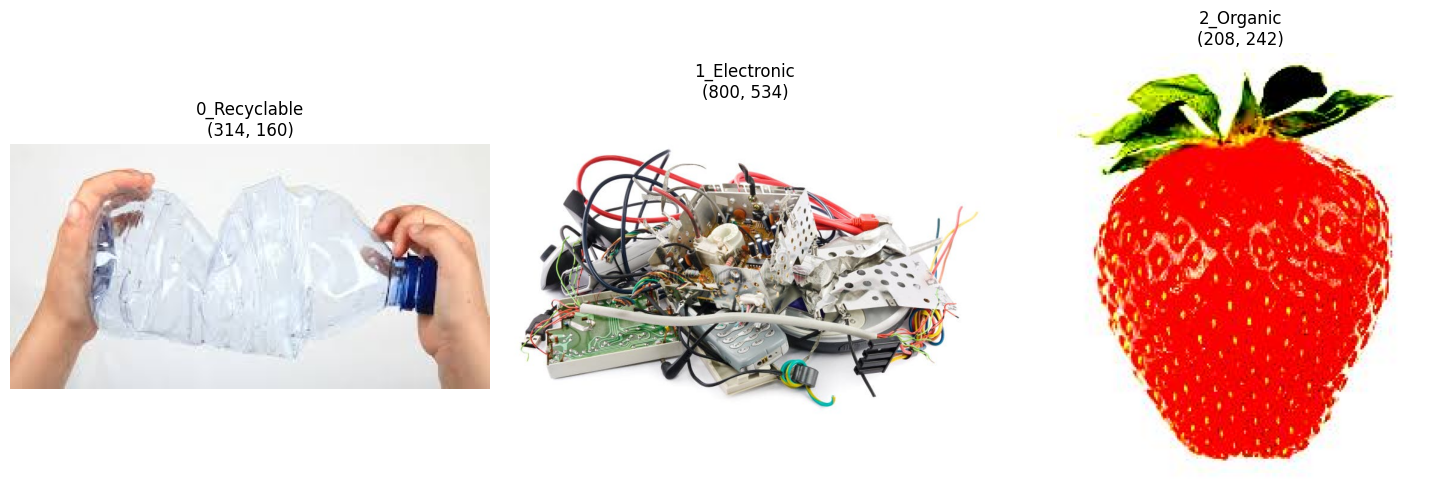

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = "/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026/BDC Satria Data 2026/train"
classes = ["0_Recyclable", "1_Electronic", "2_Organic"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cls in zip(axes, classes):
    folder = os.path.join(base_path, cls)
    first_file = sorted(os.listdir(folder))[0]
    img = Image.open(os.path.join(folder, first_file))
    ax.imshow(img)
    ax.set_title(f"{cls}\n{img.size}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# # Import library

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

# # Setting path & parameter dasar

In [4]:
base_path = "/kaggle/input/datasets/muhammadfarhanalafif/bdc-satriadata-2026/BDC Satria Data 2026"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

IMG_SIZE = (224, 224)   # semua gambar akan di-resize ke 224x224 piksel
BATCH_SIZE = 16          # model belajar 16 gambar sekaligus tiap langkah

# # Load data train

In [5]:
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.15,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.15,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Kelas:", class_names)

Found 26527 files belonging to 3 classes.
Using 22548 files for training.


I0000 00:00:1782910399.611715      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782910399.614828      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 26527 files belonging to 3 classes.
Using 3979 files for validation.
Kelas: ['0_Recyclable', '1_Electronic', '2_Organic']


# #Optimasi loading data 

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# # Data augmentation  

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# # Bangun model (transfer learning pakai EfficientNetB0) 

In [8]:
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # bekukan dulu, jangan diubah-ubah dulu bobotnya

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# # Compile model 

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# # training 

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


E0000 00:00:1782910419.379789      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1410/1410 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - accuracy: 0.8869 - loss: 0.3050 - val_accuracy: 0.9326 - val_loss: 0.1862
Epoch 2/10
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.9122 - loss: 0.2388 - val_accuracy: 0.9374 - val_loss: 0.1782
Epoch 3/10
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9136 - loss: 0.2375 - val_accuracy: 0.9407 - val_loss: 0.1686
Epoch 4/10
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9145 - loss: 0.2316 - val_accuracy: 0.9397 - val_loss: 0.1713
Epoch 5/10
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9153 - loss: 0.2279 - val_accuracy: 0.9399 - val_loss: 0.1712
Epoch 6/10
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.9160 - loss: 0.2278 - val_accuracy: 0.9440 - val_loss: 0.1667
Epoch 7/10
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9182 - loss: 0.2264 - val_accuracy: 0.9424 - val_loss: 0.1648
Epoch 8/10
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.9151 - loss: 0.23

In [11]:
model.save("/kaggle/working/model_awal.keras")
print("Model berhasil disimpan!")

Model berhasil disimpan!


# # Cek Macro F1-Score & performa per kelas 

In [12]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

# ambil semua gambar & label asli dari validation set
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# hitung macro F1
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1-Score: {macro_f1:.4f}")

# laporan detail per kelas
print("\nDetail per kelas:")
print(classification_report(y_true, y_pred, target_names=class_names))

Macro F1-Score: 0.9449

Detail per kelas:
              precision    recall  f1-score   support

0_Recyclable       0.93      0.93      0.93      1471
1_Electronic       0.94      0.96      0.95       595
   2_Organic       0.96      0.96      0.96      1913

    accuracy                           0.94      3979
   macro avg       0.94      0.95      0.94      3979
weighted avg       0.94      0.94      0.94      3979



# # Cairkan sebagian layer + compile ulang 

In [13]:
base_model.trainable = True

# hanya cairkan layer-layer di bagian akhir (yang paling "spesifik"),
# bagian awal (yang belajar pola umum seperti garis/tekstur) tetap dibekukan
fine_tune_at = 100  # EfficientNetB0 punya sekitar 237 layer, kita buka 100 terakhir

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),  # jauh lebih kecil dari sebelumnya (0.001)
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,844,191 (14.66 MB)

 Non-trainable params: 209,223 (817.28 KB)

# # training (fine-tuning) 

In [14]:
fine_tune_epochs = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

Epoch 1/5


E0000 00:00:1782911160.301687      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1410/1410 ━━━━━━━━━━━━━━━━━━━━ 161s 96ms/step - accuracy: 0.8344 - loss: 0.4274 - val_accuracy: 0.9221 - val_loss: 0.2147
Epoch 2/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 132s 94ms/step - accuracy: 0.8787 - loss: 0.3237 - val_accuracy: 0.9316 - val_loss: 0.1892
Epoch 3/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 135s 96ms/step - accuracy: 0.8978 - loss: 0.2781 - val_accuracy: 0.9379 - val_loss: 0.1730
Epoch 4/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 134s 95ms/step - accuracy: 0.9064 - loss: 0.2543 - val_accuracy: 0.9417 - val_loss: 0.1584
Epoch 5/5
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 135s 95ms/step - accuracy: 0.9133 - loss: 0.2328 - val_accuracy: 0.9419 - val_loss: 0.1516


# # Simpan model hasil fine-tuning 

In [15]:
model.save("/kaggle/working/model_finetuned.keras")
print("Model fine-tuned berhasil disimpan!")

Model fine-tuned berhasil disimpan!


In [16]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

# ambil semua gambar & label asli dari validation set
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# hitung macro F1
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1-Score: {macro_f1:.4f}")

# laporan detail per kelas
print("\nDetail per kelas:")
print(classification_report(y_true, y_pred, target_names=class_names))

Macro F1-Score: 0.9428

Detail per kelas:
              precision    recall  f1-score   support

0_Recyclable       0.92      0.93      0.93      1471
1_Electronic       0.95      0.95      0.95       595
   2_Organic       0.96      0.94      0.95      1913

    accuracy                           0.94      3979
   macro avg       0.94      0.94      0.94      3979
weighted avg       0.94      0.94      0.94      3979



# # Cairkan lebih banyak layer 

In [17]:
base_model.trainable = True

fine_tune_at = 50  # lebih sedikit dari sebelumnya (100), berarti lebih banyak layer dicairkan

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,844,191 (14.66 MB)

 Non-trainable params: 209,223 (817.28 KB)

In [18]:
extra_epochs = 8

history_fine2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=extra_epochs
)

Epoch 1/8


E0000 00:00:1782911906.449742      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1410/1410 ━━━━━━━━━━━━━━━━━━━━ 162s 96ms/step - accuracy: 0.9204 - loss: 0.2163 - val_accuracy: 0.9475 - val_loss: 0.1425
Epoch 2/8
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 133s 94ms/step - accuracy: 0.9231 - loss: 0.2068 - val_accuracy: 0.9470 - val_loss: 0.1397
Epoch 3/8
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 132s 93ms/step - accuracy: 0.9290 - loss: 0.1896 - val_accuracy: 0.9485 - val_loss: 0.1367
Epoch 4/8
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 134s 95ms/step - accuracy: 0.9343 - loss: 0.1719 - val_accuracy: 0.9500 - val_loss: 0.1315
Epoch 5/8
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 134s 95ms/step - accuracy: 0.9378 - loss: 0.1664 - val_accuracy: 0.9505 - val_loss: 0.1273
Epoch 6/8
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 135s 95ms/step - accuracy: 0.9426 - loss: 0.1550 - val_accuracy: 0.9525 - val_loss: 0.1238
Epoch 7/8
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 133s 94ms/step - accuracy: 0.9443 - loss: 0.1513 - val_accuracy: 0.9548 - val_loss: 0.1207
Epoch 8/8
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 132s 94ms/step - accuracy: 0.9465 - loss: 0.1

In [19]:
model.save("/kaggle/working/model_finetuned_v2.keras")
print("Model v2 berhasil disimpan!")

Model v2 berhasil disimpan!
